In [28]:
import numpy as np
import numpy.random as rd
import matplotlib.pyplot as plt
from pathlib import Path
from copy import deepcopy

In [29]:
import nbformat as _nbf

def _run_notebook(path, skip_cells=None):
    """Execute code cells from a notebook, skipping specified indices."""
    nb = _nbf.read(path, as_version=4)
    for i, cell in enumerate(nb.cells):
        if cell.cell_type == 'code' and (skip_cells is None or i not in skip_cells):
            exec(compile(cell.source, f'{path}:cell_{i}', 'exec'), globals())

_run_notebook("4.1_gen_vanilla_testbed.ipynb", skip_cells={4, 5})

Loaded user 118: theta_fourSC (35,), resid_fourSC (154,)
Env created OK


In [30]:
_run_notebook("RlAlgorithm.ipynb")

In [31]:
# ──────────────────────────────────────────────────────────────────
# Feature extraction helpers – replicate the feature vectors that
# Env.gen_*_mean methods construct internally, so we can build the
# design matrices the particle filter needs.
# ──────────────────────────────────────────────────────────────────

def build_fourSC_features(s, Ah):
    """Return the (35,) feature vector used by gen_fourSC_mean."""
    return np.array([
        1.0, s["fourSC_lag1"], s["yesterday_step"], s["seven_day_step_avg"],
        s["prior2hour_step"], s["Previous7DaysRPA"], s["recent_burden"],
        s["seven_day_pageview"], s["past7days_daywearing"],
        s["yesterday_planning_prompt"], s["yesterday_SalienceMessage"],
        s["Interacted_7d_walk"], s["Interacted_7d_salience"],
        s["anticipated_affect_yesterday"], s["is_weekend"], s["dow_norm"],
        s["decision_time"], s["CAE_avg_lastweek"], s["perceived_utility_lastweek"],
        Ah,
        Ah * s["yesterday_step"],       Ah * s["prior2hour_step"],
        Ah * s["recent_burden"],        Ah * s["seven_day_pageview"],
        Ah * s["past7days_daywearing"], Ah * s["yesterday_planning_prompt"],
        Ah * s["yesterday_SalienceMessage"], Ah * s["Interacted_7d_walk"],
        Ah * s["Interacted_7d_salience"], Ah * s["anticipated_affect_yesterday"],
        Ah * s["is_weekend"],           Ah * s["dow_norm"],
        Ah * s["decision_time"],        Ah * s["CAE_avg_lastweek"],
        Ah * s["perceived_utility_lastweek"],
    ])


def build_CAE_features(CAE_lastweek, week_norm, foursc_wk, antic_wk):
    """Return the (24,) feature vector used by gen_CAE_mean."""
    return np.concatenate([
        [1.0, CAE_lastweek, week_norm],
        foursc_wk.ravel(),   # 14
        antic_wk.ravel(),    #  7
    ])


def build_CAE_short_features(CAE_avg):
    """Return the (2,) feature vector used by gen_CAE_short_mean."""
    return np.array([1.0, CAE_avg])


print(f"fourSC features dim: {build_fourSC_features(make_initial_state(), 0).shape[0]}")
print(f"CAE features dim:    {build_CAE_features(0., 0., np.zeros(14), np.zeros(7)).shape[0]}")
print(f"CAE_short feat dim:  {build_CAE_short_features(0.).shape[0]}")

fourSC features dim: 35
CAE features dim:    24
CAE_short feat dim:  2


In [ ]:
# ──────────────────────────────────────────────────────────────────
# OnlineEnv: adapter that wraps Env for slot-by-slot interaction
# with the RL algorithms.
#
# Indexing convention
# -------------------
# RL uses 1-based weeks:  w = 1 .. W
# Sim uses 0-based weeks: sim_w = 0 .. nweek-1    (sim_w = w - 1)
# Days within a week:     d = 1..6 (RL-controlled), day 7 = Sunday
# Slots per day:          t = 1 or 2
# Step index:  step_idx = sim_w * 14 + (d-1)*2 + (t-1)
#
# observe_outcome(w) returns data from sim week w-2  (= RL week w-1)
# get_pf_data(w)     returns data from sim week w-2
# ──────────────────────────────────────────────────────────────────

class OnlineEnv:
    def __init__(self, env, nweek=None, seed=None, start_dow=1):
        if seed is not None:
            rd.seed(seed)

        self.env = env
        self.K = env.K
        self.W_days = env.W
        self.nweek = nweek if nweek is not None else env.cfg.nweek
        self.D = self.nweek * self.W_days
        self.T = self.D * self.K
        self.start_dow = start_dow

        self.fourSC_all = np.zeros(self.T)
        self.pageview_all = np.zeros(self.T)
        self.action_all = np.zeros(self.T)
        self.antic_all = np.zeros(self.D)
        self.fitbit_all = np.zeros(self.D)
        self.daily_all = np.zeros(self.D)
        self.CAE_all = np.full(self.nweek, np.nan)
        self.pu_all = np.full(self.nweek, np.nan)
        self.wp_all = np.full(self.nweek, np.nan)
        self.cae_short_all = np.full(self.nweek, np.nan)

        self.fourSC_cond = np.zeros((self.T, 35))
        self.CAE_cond = np.zeros((self.nweek, 24))
        self.CAE_short_cond = np.zeros((self.nweek, 2))

        self._foursc_wk = np.zeros(14)
        self._antic_wk = np.zeros(7)
        self._pw_wk = np.zeros(7)
        self._dw_wk = np.zeros(7)
        self._dp_wk = np.zeros(7)

        self._step_buf = np.zeros(self.W_days)
        self._pv_buf = np.zeros(self.W_days)
        self._wear_buf = np.zeros(self.W_days)

        self.s = make_initial_state()

        self._yesterday_morning_WS = 0.0
        self._yesterday_afternoon_WS = 0.0

        self._today_fourSC = np.zeros(self.K)
        self._today_pageview = np.zeros(self.K)
        self._today_action = np.zeros(self.K)

        self._week_finalized = np.zeros(self.nweek, dtype=bool)
        self._day_started = {}
        self._Iw_per_week = np.zeros(self.nweek, dtype=int)

        # online-available E_w entering each week
        self.E_known_all = np.full(self.nweek, np.nan)

    def start_week(self, w, I_w):
        sim_w = w - 1
        self._Iw_per_week[sim_w] = I_w
        self.E_known_all[sim_w] = self.s["perceived_utility_lastweek"]

        self._foursc_wk[:] = 0.0
        self._antic_wk[:] = 0.0
        self._pw_wk[:] = 0.0
        self._dw_wk[:] = 0.0
        self._dp_wk[:] = 0.0

    def get_week_packet(self, w):
        """Packet for the belief update at the start of RL week w."""
        sim_w_prev = w - 2
        if sim_w_prev < 0:
            return None

        self._finalize_week(sim_w_prev)

        pf_data = self.get_pf_data(w)

        y_prev = self.CAE_all[sim_w_prev]
        ty_prev = self.cae_short_all[sim_w_prev]

        return WeekPacket(
            w=w,
            pf_data=pf_data,
            Y_prev=None if np.isnan(y_prev) else float(y_prev),
            tY_prev=None if np.isnan(ty_prev) else float(ty_prev),
        )

    def run_episode(self, agent):
        agent.reset()

        for w in range(1, self.nweek + 1):
            packet = self.get_week_packet(w)
            I_w = agent.begin_week(w, packet)

            self.start_week(w, I_w)

            for d in range(1, 7):
                for t in range(1, 3):
                    state = self.get_state(w, d, t)
                    A_wdt = agent.act(w, d, t, state)
                    self.step_action(w, d, t, A_wdt, I_w)

            self._finalize_week(w - 1)

        return agent.results()

    def step_action(self, w, d, t, action, I_w):
        sim_w = w - 1
        d_w = d - 1
        t_sim = t - 1
        d_global = sim_w * self.W_days + d_w
        step_idx = sim_w * 14 + d_w * 2 + t_sim

        self._Iw_per_week[sim_w] = I_w

        if t_sim == 0 and (sim_w, d_w) not in self._day_started:
            self._day_started[(sim_w, d_w)] = True
            self._start_day(sim_w, d_w, d_global, I_w)

        self.s["decision_time"] = float(t_sim)
        Ah = float(action)

        x_fourSC = build_fourSC_features(self.s, Ah)
        fourSC = self.env.gen_fourSC(self.s, Ah, step_idx)
        pv = self.env.gen_pageview(self.s, Ah, I_w, step_idx)

        self.fourSC_all[step_idx] = fourSC
        self.pageview_all[step_idx] = pv
        self.action_all[step_idx] = Ah
        self.fourSC_cond[step_idx] = x_fourSC
        self._today_fourSC[t_sim] = fourSC
        self._today_pageview[t_sim] = pv
        self._today_action[t_sim] = Ah
        self._foursc_wk[d_w * self.K + t_sim] = fourSC

        self.s["fourSC_lag1"] = fourSC
        self.s["hourly_pageview_lag1"] = pv
        self.s["prior2hour_step"] = fourSC

        if t_sim == self.K - 1:
            self._end_day(sim_w, d_w, d_global)

    def _start_day(self, sim_w, d_w, d_global, Iw):
        d_abs = d_global
        dow = ((self.start_dow - 1 + d_abs) % 7) + 1
        self.s["dow_norm"] = dow / 7.0
        self.s["is_weekend"] = 1.0 if dow >= 6 else 0.0

        ws_m = self._yesterday_morning_WS
        ws_a = self._yesterday_afternoon_WS

        fitbit = self.env.gen_fitbitwearing(self.s, ws_m, ws_a, Iw, d_global)
        self.s["fitbitwearing_morning"] = fitbit

        daily_pres = self.env.gen_dailysurvey(self.s, ws_m, ws_a, Iw, d_global)
        self.s["daily_present"] = daily_pres

        antic = self.env.gen_antic(self.s, ws_m, ws_a, d_global)

        self.fitbit_all[d_global] = fitbit
        self.daily_all[d_global] = daily_pres
        self.antic_all[d_global] = antic
        self._current_antic = antic

        self._today_fourSC[:] = 0.0
        self._today_pageview[:] = 0.0
        self._today_action[:] = 0.0

    def _end_day(self, sim_w, d_w, d_global):
        daily_mean_step = np.mean(self._today_fourSC)
        daily_mean_pv = np.mean(self._today_pageview)
        antic = self._current_antic
        fitbit = self.fitbit_all[d_global]
        daily_pres = self.daily_all[d_global]

        self.s["yesterday_step"] = daily_mean_step
        self.s["yesterday_fitbitwearing"] = fitbit
        self.s["yesterday_present"] = daily_pres
        self.s["yesterday_pageview_morning"] = self._today_pageview[0]
        self.s["yesterday_pageview_afternoon"] = self._today_pageview[1]
        self.s["dow_norm_lag1"] = self.s["dow_norm"]
        self.s["anticipated_affect_lag1"] = self.s["anticipated_affect_yesterday"]
        self.s["anticipated_affect_yesterday"] = antic

        self._step_buf[d_global % self.W_days] = daily_mean_step
        self._pv_buf[d_global % self.W_days] = daily_mean_pv
        self._wear_buf[d_global % self.W_days] = fitbit
        n_buf = min(d_global + 1, self.W_days)

        self.s["seven_day_step_avg"] = np.sum(self._step_buf) / n_buf
        self.s["seven_day_pageview"] = np.sum(self._pv_buf) / n_buf
        self.s["past7days_daywearing"] = np.sum(self._wear_buf) / n_buf

        self._yesterday_morning_WS = self._today_action[0]
        self._yesterday_afternoon_WS = self._today_action[1]

        self._antic_wk[d_w] = antic
        self._pw_wk[d_w] = daily_mean_pv
        self._dw_wk[d_w] = fitbit
        self._dp_wk[d_w] = daily_pres

    def _finalize_week(self, sim_w):
        if sim_w < 0 or sim_w >= self.nweek or self._week_finalized[sim_w]:
            return

        Iw = self._Iw_per_week[sim_w]
        d_w_sun = 6
        d_global = sim_w * self.W_days + d_w_sun
        week_norm = (sim_w + 1) / self.nweek   # use self.nweek, not env.cfg.nweek

        if (sim_w, d_w_sun) not in self._day_started:
            self._day_started[(sim_w, d_w_sun)] = True
            self._start_day(sim_w, d_w_sun, d_global, Iw)

        for t_sim in range(self.K):
            step_idx = sim_w * 14 + d_w_sun * 2 + t_sim
            Ah = 0.0
            self.s["decision_time"] = float(t_sim)

            x_fourSC = build_fourSC_features(self.s, Ah)
            fourSC = self.env.gen_fourSC(self.s, Ah, step_idx)
            pv = self.env.gen_pageview(self.s, Ah, Iw, step_idx)

            self.fourSC_all[step_idx] = fourSC
            self.pageview_all[step_idx] = pv
            self.action_all[step_idx] = Ah
            self.fourSC_cond[step_idx] = x_fourSC
            self._today_fourSC[t_sim] = fourSC
            self._today_pageview[t_sim] = pv
            self._today_action[t_sim] = Ah
            self._foursc_wk[d_w_sun * self.K + t_sim] = fourSC

            self.s["fourSC_lag1"] = fourSC
            self.s["hourly_pageview_lag1"] = pv
            self.s["prior2hour_step"] = fourSC

        self._end_day(sim_w, d_w_sun, d_global)

        cae = self.env.gen_CAE(
            self.s["CAE_avg_lastweek"], week_norm,
            self._foursc_wk, self._antic_wk, sim_w,
        )
        pu = self.env.gen_perceived_utility(
            self.s["perceived_utility_lastweek"], week_norm,
            self._pw_wk, self._dw_wk, self._dp_wk, sim_w,
        )
        wp = self.env.gen_week_present(pu, sim_w)
        cs = self.env.gen_CAE_short(cae, sim_w)

        self.CAE_all[sim_w] = cae
        self.pu_all[sim_w] = pu
        self.wp_all[sim_w] = wp
        self.cae_short_all[sim_w] = cs

        self.CAE_cond[sim_w] = build_CAE_features(
            self.s["CAE_avg_lastweek"], week_norm,
            self._foursc_wk, self._antic_wk,
        )
        self.CAE_short_cond[sim_w] = build_CAE_short_features(cae)

        self.s["CAE_avg_lastweek"] = cae
        self.s["perceived_utility_lastweek"] = pu

        self._week_finalized[sim_w] = True

    def get_pf_data(self, w):
        sim_w_prev = w - 2
        K14 = 14
        ar1_col = 1

        if sim_w_prev >= 0:
            self._finalize_week(sim_w_prev)

        start_row = sim_w_prev * K14
        prev_rows = list(range(start_row, start_row + 12))

        X_MY, M_Y_obs = [], []
        for m, r in enumerate(prev_rows):
            x = self.fourSC_cond[r].copy()
            if m == 0:
                x[ar1_col] = 0.0
            X_MY.append(x)
            M_Y_obs.append(self.fourSC_all[r])

        X_Y = self.CAE_cond[sim_w_prev]
        X_tilde_Y = self.CAE_short_cond[sim_w_prev]

        if w >= 3:
            X_cumul_MY, y_cumul_MY = [], []
            for m in range(12):
                slot_rows = [sw * K14 + m for sw in range(0, sim_w_prev)]
                X_m = self.fourSC_cond[slot_rows].copy()
                y_m = self.fourSC_all[slot_rows].copy()
                if m == 0:
                    X_m[:, ar1_col] = 0.0
                X_cumul_MY.append(X_m)
                y_cumul_MY.append(y_m)

            X_cumul_Y = self.CAE_cond[:sim_w_prev]
            y_cumul_Y = self.CAE_all[:sim_w_prev]
            X_cumul_tY = self.CAE_short_cond[:sim_w_prev]
            y_cumul_tY = self.cae_short_all[:sim_w_prev]
        else:
            X_cumul_MY = y_cumul_MY = None
            X_cumul_Y = y_cumul_Y = None
            X_cumul_tY = y_cumul_tY = None

        return {
            "X_MY": X_MY,
            "M_Y_obs": M_Y_obs,
            "X_Y": X_Y,
            "X_tilde_Y": X_tilde_Y,
            "X_cumul_MY": X_cumul_MY,
            "y_cumul_MY": y_cumul_MY,
            "X_cumul_Y": X_cumul_Y,
            "y_cumul_Y": y_cumul_Y,
            "X_cumul_tY": X_cumul_tY,
            "y_cumul_tY": y_cumul_tY,
        }

    def get_state(self, w, d, t):
        sim_w = w - 1
        E_w = self.E_known_all[sim_w] if (
            0 <= sim_w < self.nweek and not np.isnan(self.E_known_all[sim_w])
        ) else 0.0

        if d == 0 and t == 0:
            return {
                "E_w": E_w,
                "M_Y": np.zeros((6, 2)),
                "M_E": np.zeros((6, 2)),
                "C": np.array([]),
            }

        M_Y = np.zeros((6, 2))
        M_E = np.zeros((6, 2))

        for dd in range(1, 7):
            for tt in range(1, 3):
                if (dd, tt) < (d, t):
                    r = sim_w * 14 + (dd - 1) * 2 + (tt - 1)
                    if r < self.T:
                        M_Y[dd - 1, tt - 1] = self.fourSC_all[r]
                        M_E[dd - 1, tt - 1] = self.pageview_all[r]

        return {"E_w": E_w, "M_Y": M_Y, "M_E": M_E, "C": np.array([])}

    def reward_fn(self, wp):
        """Surrogate reward for RL week wp (returns CAE from sim week wp-1)."""
        sim_w = wp - 1
        if 0 <= sim_w < self.nweek and not np.isnan(self.CAE_all[sim_w]):
            return self.CAE_all[sim_w]
        return 0.0


print("OnlineEnv defined.")

OnlineEnv defined.


In [ ]:
# ──────────────────────────────────────────────────────────────────
# Placeholder priors and hyperparameters
# ──────────────────────────────────────────────────────────────────

N_MED = 12   # mediator model slots (6 days × 2 slots)
P_MED = 35   # fourSC feature dimension
P_CAE = 24   # CAE model feature dimension
P_TY  = 2    # CAE_short model feature dimension

P_RL_MICRO = 69   # build_phi_action  with n_c=0:   9+24+12*3
P_RL_QUERY = 72   # build_phi_action_query with n_c=0: 9+24+13*3

# ── mediator model priors ──
nu_0_MY    = [np.zeros(P_MED) for _ in range(N_MED)]
Gamma_0_MY = [np.eye(P_MED)   for _ in range(N_MED)]
sigma2_MY  = [1.0] * N_MED

# ── Y model (CAE) ──
nu_0_Y    = np.zeros(P_CAE)
Gamma_0_Y = np.eye(P_CAE)
sigma2_Y  = 1.0

# ── tilde_Y model (CAE_short) ──
nu_0_tilde_Y    = np.zeros(P_TY)
Gamma_0_tilde_Y = np.eye(P_TY)
sigma2_tilde_Y  = 1.0

# ── RL hyperparameters (shared) ──

GAMMA_BAR    = 0.5
GAMMA_DT_micro     = (GAMMA_BAR ** (1.0 / 12)) * np.ones((6, 2))
GAMMA_DT_query     = (GAMMA_BAR ** (1.0 / 13)) * np.ones((6, 2))
GAMMA_QUERY  = GAMMA_BAR ** (1.0 / 13)   # 13th root of γ_bar
TARGET_C     = 2
EPSILON_0    = 0.1
J_PARTICLES  = 100
B_ENSEMBLES  = 10
Y1_BASELINE  = 0.0
NWEEK        = 20

# RL priors (per-algorithm dimensions)
def _rl_priors(p_rl):
    return (np.zeros(p_rl), 10.0 * np.eye(p_rl), 1.0)

mu_0_micro, Sigma_0_micro, sigma2_rl_micro = _rl_priors(P_RL_MICRO)
mu_0_query, Sigma_0_query, sigma2_rl_query = _rl_priors(P_RL_QUERY)

print(f"Priors ready:  p_rl(micro)={P_RL_MICRO}, p_rl(query)={P_RL_QUERY}")

Priors ready:  p_rl(micro)=69, p_rl(query)=72


In [ ]:
# ──────────────────────────────────────────────────────────────────
# Run one participant with a given algorithm
# ──────────────────────────────────────────────────────────────────

def run_micro_query(uid, seed=42):
    cfg = EnvConfig(uid)
    nweek = cfg.nweek
    env = Env(cfg, noise="sequential")
    oenv = OnlineEnv(env, nweek=nweek, seed=seed)

    agent = MicroQueryAgent(
        W=nweek, J=J_PARTICLES, B=B_ENSEMBLES, epsilon_0=EPSILON_0,
        mu_0_rl=mu_0_micro, Sigma_0_rl=Sigma_0_micro, sigma2_rl=sigma2_rl_micro,
        gamma_dt=GAMMA_DT_micro, gamma_bar=GAMMA_BAR, target_update_C=TARGET_C,
        nu_0_MY=nu_0_MY, Gamma_0_MY=Gamma_0_MY, sigma2_MY=sigma2_MY,
        nu_0_Y=nu_0_Y, Gamma_0_Y=Gamma_0_Y, sigma2_Y=sigma2_Y,
        nu_0_tilde_Y=nu_0_tilde_Y, Gamma_0_tilde_Y=Gamma_0_tilde_Y,
        sigma2_tilde_Y=sigma2_tilde_Y,
        Y_1=Y1_BASELINE,
        get_state=oenv.get_state,
        reward_fn=oenv.reward_fn,
        rng=np.random.default_rng(seed),
    )

    result = oenv.run_episode(agent)
    return result, oenv


def run_rl_query(uid, seed=42):
    cfg = EnvConfig(uid)
    nweek = cfg.nweek
    env = Env(cfg, noise="sequential")
    oenv = OnlineEnv(env, nweek=nweek, seed=seed)

    agent = RLQueryAgent(
        W=nweek, J=J_PARTICLES, B=B_ENSEMBLES, epsilon_0=EPSILON_0,
        mu_0_rl=mu_0_query, Sigma_0_rl=Sigma_0_query, sigma2_rl=sigma2_rl_query,
        gamma_dt=GAMMA_DT_query, gamma_bar=GAMMA_BAR,
        gamma_query=GAMMA_QUERY, target_update_C=TARGET_C,
        nu_0_MY=nu_0_MY, Gamma_0_MY=Gamma_0_MY, sigma2_MY=sigma2_MY,
        nu_0_Y=nu_0_Y, Gamma_0_Y=Gamma_0_Y, sigma2_Y=sigma2_Y,
        nu_0_tilde_Y=nu_0_tilde_Y, Gamma_0_tilde_Y=Gamma_0_tilde_Y,
        sigma2_tilde_Y=sigma2_tilde_Y,
        Y_1=Y1_BASELINE,
        get_state=oenv.get_state,
        reward_fn=oenv.reward_fn,
        rng=np.random.default_rng(seed),
    )

    result = oenv.run_episode(agent)
    return result, oenv


print("Runner functions defined.")

Runner functions defined.


In [35]:
# ──────────────────────────────────────────────────────────────────
# Main experiment: run both algorithms for all users
# ──────────────────────────────────────────────────────────────────

user_ids = np.loadtxt(PARAMS_DIR / "user_ids.txt", dtype=int)
N_EXPERIMENTS = 10
SEEDS = list(range(N_EXPERIMENTS))  # seeds 0, 1, …, 9

cae_micro = {}   # uid -> (n_seeds, nweek)
cae_query = {}
piA_micro = {}   # uid -> (n_seeds, W+1, 6, 2)
piA_query = {}

for uid in user_ids:
    cae_m_list, cae_q_list = [], []
    piA_m_list, piA_q_list = [], []

    for seed in SEEDS:
        print(f"  User {uid}, seed {seed} ... ", end="", flush=True)

        res_m, oenv_m = run_micro_query(uid, seed=seed)
        res_q, oenv_q = run_rl_query(uid, seed=seed)

        cae_m_list.append(oenv_m.CAE_all.copy())
        cae_q_list.append(oenv_q.CAE_all.copy())
        piA_m_list.append(res_m['pi_A'].copy())
        piA_q_list.append(res_q['pi_A'].copy())
        print(f"micro CAE mean={oenv_m.CAE_all.mean():.3f}, "
              f"query CAE mean={oenv_q.CAE_all.mean():.3f}")

    cae_micro[uid] = np.stack(cae_m_list)
    cae_query[uid] = np.stack(cae_q_list)
    piA_micro[uid] = np.stack(piA_m_list)
    piA_query[uid] = np.stack(piA_q_list)

print("\nExperiment complete.")

  User 118, seed 0 ... micro CAE mean=1.115, query CAE mean=1.111
  User 118, seed 1 ... micro CAE mean=1.113, query CAE mean=1.113
  User 118, seed 2 ... micro CAE mean=1.122, query CAE mean=1.123
  User 118, seed 3 ... micro CAE mean=1.123, query CAE mean=1.125
  User 118, seed 4 ... micro CAE mean=1.125, query CAE mean=1.127
  User 118, seed 5 ... micro CAE mean=1.134, query CAE mean=1.132
  User 118, seed 6 ... micro CAE mean=1.103, query CAE mean=1.110
  User 118, seed 7 ... micro CAE mean=1.130, query CAE mean=1.129
  User 118, seed 8 ... micro CAE mean=1.118, query CAE mean=1.120
  User 118, seed 9 ... micro CAE mean=1.116, query CAE mean=1.112
  User 141, seed 0 ... micro CAE mean=0.730, query CAE mean=0.738
  User 141, seed 1 ... micro CAE mean=0.730, query CAE mean=0.737
  User 141, seed 2 ... micro CAE mean=0.724, query CAE mean=0.728
  User 141, seed 3 ... micro CAE mean=0.735, query CAE mean=0.737
  User 141, seed 4 ... micro CAE mean=0.737, query CAE mean=0.735
  User 141

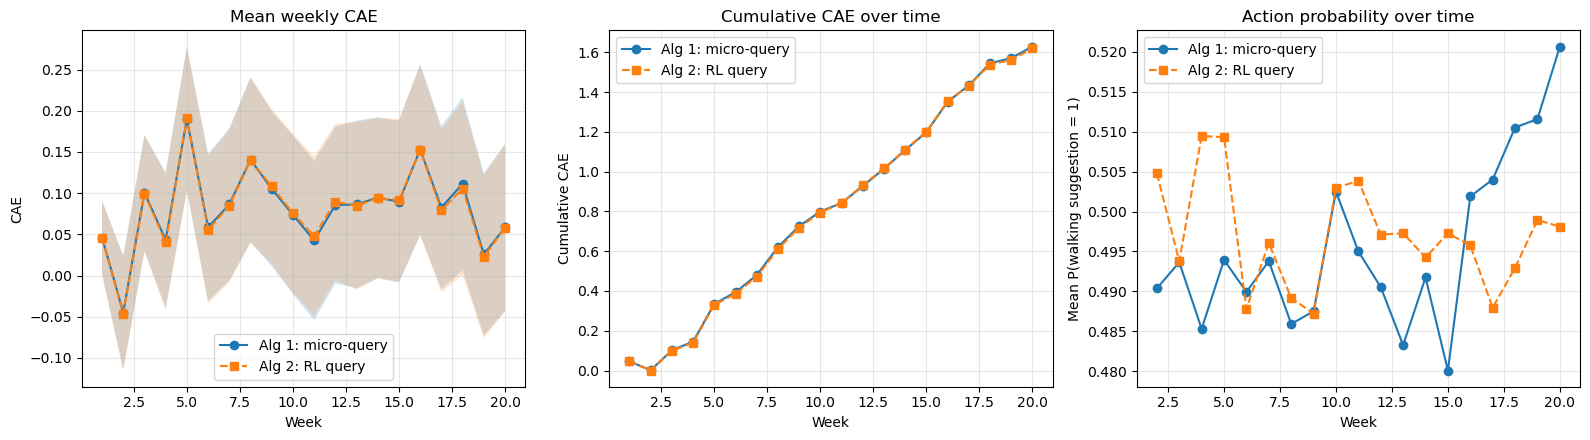

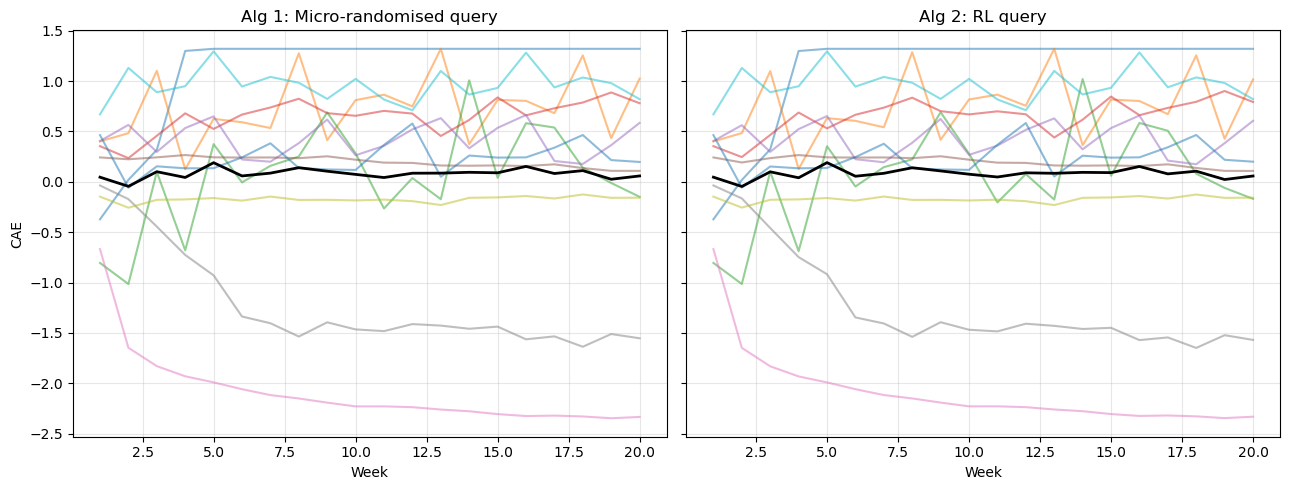


Metric                         Alg 1 (micro)   Alg 2 (RL)
-------------------------------------------------------
Mean CAE (all weeks)                 0.0814       0.0810
Mean CAE (weeks 3-11)                0.0904       0.0900
Cumulative CAE (total)               1.6289       1.6190


In [36]:
# ──────────────────────────────────────────────────────────────────
# Visualise results
# ──────────────────────────────────────────────────────────────────

weeks = np.arange(1, NWEEK + 1)

# aggregate across users and seeds: shape (n_users * n_seeds, nweek)
all_micro = np.vstack([cae_micro[uid] for uid in user_ids])
all_query = np.vstack([cae_query[uid] for uid in user_ids])

mean_micro = all_micro.mean(axis=0)
mean_query = all_query.mean(axis=0)
se_micro   = all_micro.std(axis=0) / np.sqrt(all_micro.shape[0])
se_query   = all_query.std(axis=0) / np.sqrt(all_query.shape[0])

# ── 1. Mean weekly CAE ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
ax.plot(weeks, mean_micro, "o-", label="Alg 1: micro-query")
ax.fill_between(weeks, mean_micro - se_micro, mean_micro + se_micro, alpha=0.2)
ax.plot(weeks, mean_query, "s--", label="Alg 2: RL query")
ax.fill_between(weeks, mean_query - se_query, mean_query + se_query, alpha=0.2)
ax.set_xlabel("Week")
ax.set_ylabel("CAE")
ax.set_title("Mean weekly CAE")
ax.legend()
ax.grid(True, alpha=0.3)

# ── 2. Cumulative CAE ──
ax = axes[1]
cum_micro = np.cumsum(mean_micro)
cum_query = np.cumsum(mean_query)
ax.plot(weeks, cum_micro, "o-", label="Alg 1: micro-query")
ax.plot(weeks, cum_query, "s--", label="Alg 2: RL query")
ax.set_xlabel("Week")
ax.set_ylabel("Cumulative CAE")
ax.set_title("Cumulative CAE over time")
ax.legend()
ax.grid(True, alpha=0.3)

# ── 3. Mean action probability over weeks ──
ax = axes[2]
# average pi_A across (d, t, users, seeds): shape (W+1, 6, 2) -> per-week mean
for uid in user_ids:
    piA_m_list = piA_micro[uid]
    piA_q_list = piA_query[uid]

# stack across users: (n_users, n_seeds, W+1, 6, 2)
piA_m_all = np.stack([piA_micro[uid] for uid in user_ids])
piA_q_all = np.stack([piA_query[uid] for uid in user_ids])
# mean over (users, seeds, days, slots) -> per-week
piA_m_mean = np.nanmean(piA_m_all[:, :, 2:, :, :], axis=(0, 1, 3, 4))  # weeks 2..W
piA_q_mean = np.nanmean(piA_q_all[:, :, 2:, :, :], axis=(0, 1, 3, 4))
rl_weeks = np.arange(2, NWEEK + 1)
ax.plot(rl_weeks, piA_m_mean, "o-", label="Alg 1: micro-query")
ax.plot(rl_weeks, piA_q_mean, "s--", label="Alg 2: RL query")
ax.set_xlabel("Week")
ax.set_ylabel("Mean P(walking suggestion = 1)")
ax.set_title("Action probability over time")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

# ── 4. Per-user CAE trajectories ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

ax = axes[0]
ax.set_title("Alg 1: Micro-randomised query")
for uid in user_ids:
    ax.plot(weeks, cae_micro[uid].mean(axis=0), alpha=0.5, label=f"User {uid}")
ax.plot(weeks, mean_micro, "k-", linewidth=2, label="Mean")
ax.set_xlabel("Week")
ax.set_ylabel("CAE")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.set_title("Alg 2: RL query")
for uid in user_ids:
    ax.plot(weeks, cae_query[uid].mean(axis=0), alpha=0.5, label=f"User {uid}")
ax.plot(weeks, mean_query, "k-", linewidth=2, label="Mean")
ax.set_xlabel("Week")
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

# ── Summary table ──
print("\n" + "=" * 55)
print(f"{'Metric':<30} {'Alg 1 (micro)':>12} {'Alg 2 (RL)':>12}")
print("-" * 55)
print(f"{'Mean CAE (all weeks)':<30} {all_micro.mean():>12.4f} {all_query.mean():>12.4f}")
print(f"{'Mean CAE (weeks 3-11)':<30} {all_micro[:, 2:].mean():>12.4f} {all_query[:, 2:].mean():>12.4f}")
print(f"{'Cumulative CAE (total)':<30} {cum_micro[-1]:>12.4f} {cum_query[-1]:>12.4f}")
print("=" * 55)